# FPV attenuation factor analysis

Author: Sofia Midauar

Date: January 2025

In [33]:
import pandas as pd
import xarray as xr
import glob2 as glob
from scipy.interpolate import interp1d
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
# folder path to save figures
figs_path = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_comp/'

In [5]:
# Creates list with depth of measurements
depth_obs = [0.5, 1, 2, 3, 4, 5, 6, 7]
depth_obs_str = []

for i in depth_obs:
    name = (str(i) + 'm')
    depth_obs_str.append(name)
    
depth_obs_str

['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']

## Read data

In [6]:
# Read folder locations for all the runs 
folder_runs = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_attenuation_factor/'
output_paths = sorted(glob.glob(folder_runs + '*/', recursive = True))

Dictionary_WT_underFPV = {}

for folder in range(len(output_paths)-1):
    names = glob.glob(output_paths[folder] + 'trim*.nc')
    output = xr.open_dataset(names[0])
    output_temp_underFPV = output[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)
    output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR
    data_modelled = np.empty((len(output_temp_underFPV.time.values), 8))
    # calculates temperature per depth (matching measurements) for each timestep
    for i in range(len(output_temp_underFPV.time.values)):
        output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
        depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
        temp = output_temp_underFPV_t.R1.values # gets water temperature value
        time = output_temp_underFPV_t.time.values # gets timestep analysed
        temp = temp[depth > 0] # gets temperature values for depth > 0
        depth = depth[depth > 0] # gets depth values > 0
        f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
        data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep
    # Creates new dataframe with information on time and depth of the modelled temperature
    WT_underFPV_modelled = pd.DataFrame(data_modelled)
    times_t = pd.DataFrame(output_temp_underFPV.time.values)
    WT_underFPV_modelled['time'] = times_t
    WT_underFPV_modelled.set_index('time', inplace = True)
    WT_underFPV_modelled.columns = depth_obs_str
    # creates dictionary with all model outputs from the multiple attenuation factors
    name = (os.path.basename(names[0])[24:-3])
    Dictionary_WT_underFPV[name] = WT_underFPV_modelled.copy()

Dictionary_WT_underFPV

{'factor1':                           0.5m         1m         2m         3m         4m  \
 time                                                                         
 2022-09-09 00:00:00  25.645449  25.591359  25.478496  25.359496  25.392140   
 2022-09-09 06:00:00  25.185508  25.192014  25.202716  25.209000  25.212645   
 2022-09-09 12:00:00  25.186158  25.194370  25.207578  25.214180  25.200924   
 2022-09-09 18:00:00  25.172107  25.182053  25.198012  25.206333  25.207990   
 2022-09-10 00:00:00  24.893789  24.900587  24.911711  24.918244  24.922222   
 ...                        ...        ...        ...        ...        ...   
 2024-03-14 00:00:00  10.051177  10.030047   9.684963   9.167169   8.651733   
 2024-03-14 06:00:00  11.094680  11.072684  10.433621   9.531924   8.894052   
 2024-03-14 12:00:00  10.549717  10.549057  10.486977   9.918580   9.183633   
 2024-03-14 18:00:00  10.196389  10.205460  10.217034  10.050225   9.389370   
 2024-03-15 00:00:00  10.006040  10.01198

## Breaks down surface (up to 5m) data

In [7]:
## CREATE DIC WITH WT FOR UP TO 5M DEEP - TO COMPARE WITH EMPIRICAL DATA
# Creates df with bias - one column per depth
runs_names = list(Dictionary_WT_underFPV.keys())
Dictionary_underFPV_surface = {}

# Add columns for other depths
for run in runs_names:
    temporary = Dictionary_WT_underFPV[run].copy()
    temp_surface = temporary[temporary.columns[:6]].copy()
    temp_surface['averaged_WT_surface'] = temp_surface.mean(axis=1)
    Dictionary_underFPV_surface[(run + '_surface')] = temp_surface.copy()

Dictionary_underFPV_surface.keys()

dict_keys(['factor1_surface', 'factor045_surface', '9_surface', 'factor055_surface', 'factor060_surface', 'factor065_surface', 'factor070_surface'])

In [8]:
# Creates df with bias FOR SURFACE - one column per depth
runs_names = list(Dictionary_underFPV_surface.keys())
WT_noFPV_underFPV_surface = Dictionary_underFPV_surface['factor1_surface'].copy()
Dictionary_bias_underFPV_surface = {}

# Add columns for other depths
for run in runs_names[:-1]:
    temporary = Dictionary_underFPV_surface[run].copy()
    temp_bias_surf = pd.DataFrame(temporary.index)
    temp_bias_surf.set_index('time', inplace = True)
    for depth in range(0, len(depth_obs)-2, 1):
        temp_bias_surf['bias_surf_' + 
                       depth_obs_str[depth]] = (temporary[temporary.columns[depth]] - 
                                                WT_noFPV_underFPV_surface[WT_noFPV_underFPV_surface.columns[depth]])
    temp_bias_surf['averaged_bias'] = temp_bias_surf.mean(axis=1)
    Dictionary_bias_underFPV_surface[(run + '_bias_surface')] = temp_bias_surf.copy()

Dictionary_bias_underFPV_surface

{'factor1_surface_bias_surface':                      bias_surf_0.5m  bias_surf_1m  bias_surf_2m  bias_surf_3m  \
 time                                                                            
 2022-09-09 00:00:00             0.0           0.0           0.0           0.0   
 2022-09-09 06:00:00             0.0           0.0           0.0           0.0   
 2022-09-09 12:00:00             0.0           0.0           0.0           0.0   
 2022-09-09 18:00:00             0.0           0.0           0.0           0.0   
 2022-09-10 00:00:00             0.0           0.0           0.0           0.0   
 ...                             ...           ...           ...           ...   
 2024-03-14 00:00:00             0.0           0.0           0.0           0.0   
 2024-03-14 06:00:00             0.0           0.0           0.0           0.0   
 2024-03-14 12:00:00             0.0           0.0           0.0           0.0   
 2024-03-14 18:00:00             0.0           0.0           0.0  

In [9]:
# Create df with WT for all model runs
model_runs = list(Dictionary_bias_underFPV_surface.keys())

for run in range(0,len(model_runs), 1):
    temp_WT = Dictionary_bias_underFPV_surface[model_runs[run]].copy()
    temp_WT = pd.DataFrame(temp_WT[temp_WT.columns[-1]])
    temp_WT.rename(columns = {temp_WT.columns[0]:
                              (list(Dictionary_bias_underFPV_surface.keys())[run])},
                   inplace = True)
    if run == 0:
        factor_bias_surface = temp_WT.copy()
    else:
        factor_bias_surface = factor_bias_surface.merge(temp_WT, on = 'time')
        
factor_bias_surface.head(2)

,factor1_surface_bias_surface,factor045_surface_bias_surface,9_surface_bias_surface,factor055_surface_bias_surface,factor060_surface_bias_surface,factor065_surface_bias_surface
time,,,,,,
2022-09-09 00:00:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.0,0.006139,0.005562,0.004992,0.004441,0.003908


# Compare runs

In [7]:
Dictionary_WT_underFPV['factor050'] = Dictionary_WT_underFPV['9']
del Dictionary_WT_underFPV['9']
Dictionary_WT_underFPV.keys()

dict_keys(['factor1', 'factor045', 'factor055', 'factor060', 'factor065', 'factor070', 'factor050'])

In [8]:
Dictionary_WT_underFPV = dict(sorted(Dictionary_WT_underFPV.items()))
Dictionary_WT_underFPV.keys()

dict_keys(['factor045', 'factor050', 'factor055', 'factor060', 'factor065', 'factor070', 'factor1'])

In [9]:
# Create df with WT for all model runs
model_runs = list(Dictionary_WT_underFPV.keys())

for run in range(0,len(model_runs), 1):
    temp_WT = Dictionary_WT_underFPV[model_runs[run]].copy()
    temp_WT = pd.DataFrame(temp_WT[temp_WT.columns[-1]])
    temp_WT.rename(columns = {temp_WT.columns[0]:
                              (list(Dictionary_WT_underFPV.keys())[run])},
                   inplace = True)
    if run == 0:
        factor_WT = temp_WT.copy()
    else:
        factor_WT = factor_WT.merge(temp_WT, on = 'time')
        
factor_WT.head(2)

,factor045,factor050,factor055,factor060,factor065,factor070,factor1
time,,,,,,,
2022-09-09 00:00:00,24.473604,24.473604,24.473604,24.473604,24.473604,24.473604,24.473604
2022-09-09 06:00:00,24.486989,24.487047,24.487105,24.487141,24.487158,24.487259,24.487643


In [10]:
# Create df with WT for all model runs
model_runs = list(Dictionary_underFPV_surface.keys())

for run in range(0,len(model_runs), 1):
    temp_WT = Dictionary_underFPV_surface[model_runs[run]].copy()
    temp_WT = pd.DataFrame(temp_WT[temp_WT.columns[-1]])
    temp_WT.rename(columns = {temp_WT.columns[0]:
                              (list(Dictionary_underFPV_surface.keys())[run])},
                   inplace = True)
    if run == 0:
        factor_WT_surface = temp_WT.copy()
    else:
        factor_WT_surface = factor_WT_surface.merge(temp_WT, on = 'time')
        
factor_WT_surface.head(2)

NameError: name 'Dictionary_underFPV_surface' is not defined

In [11]:
# Creates df with bias - one column per depth
runs_names = list(Dictionary_WT_underFPV.keys())
WT_noFPV_underFPV = Dictionary_WT_underFPV['factor1'].copy()
Dictionary_bias_underFPV = {}

# Add columns for other depths
for run in runs_names[:-1]:
    temporary = Dictionary_WT_underFPV[run].copy()
    temp_bias = pd.DataFrame(temporary.index)
    temp_bias.set_index('time', inplace = True)
    for depth in range(0, len(depth_obs), 1):
        temp_bias['bias_' + depth_obs_str[depth]] = (temporary[temporary.columns[depth]] - 
                                                     WT_noFPV_underFPV[WT_noFPV_underFPV.columns[depth]])
    temp_bias['averaged_bias'] = temp_bias.mean(axis=1)
    Dictionary_bias_underFPV[(run + '_bias')] = temp_bias.copy()

Dictionary_bias_underFPV

{'factor045_bias':                      bias_0.5m   bias_1m   bias_2m   bias_3m   bias_4m  \
 time                                                                     
 2022-09-09 00:00:00   0.000000  0.000000  0.000000  0.000000  0.000000   
 2022-09-09 06:00:00   0.007236  0.006961  0.006507  0.006202  0.005853   
 2022-09-09 12:00:00  -0.044685 -0.045930 -0.047381 -0.046437 -0.028357   
 2022-09-09 18:00:00  -0.078509 -0.081646 -0.086232 -0.087482 -0.084645   
 2022-09-10 00:00:00  -0.048262 -0.049351 -0.050896 -0.051224 -0.050699   
 ...                        ...       ...       ...       ...       ...   
 2024-03-14 00:00:00  -2.857032 -2.857329 -3.014713 -2.856447 -2.901865   
 2024-03-14 06:00:00  -2.934203 -2.928120 -3.293430 -3.045770 -3.037063   
 2024-03-14 12:00:00  -2.701718 -2.701058 -2.842922 -3.330542 -3.257348   
 2024-03-14 18:00:00  -2.722463 -2.711566 -2.713968 -3.164028 -3.392310   
 2024-03-15 00:00:00  -2.680959 -2.672116 -2.674465 -3.037862 -3.405613   
 
     

In [12]:
# Create df with bias for all model runs
model_runs = list(Dictionary_bias_underFPV.keys())

for run in range(0,len(model_runs), 1):
    temp_bias = Dictionary_bias_underFPV[model_runs[run]].copy()
    temp_bias = pd.DataFrame(temp_bias[temp_bias.columns[-1]])
    temp_bias.rename(columns = {temp_bias.columns[0]:
                                (list(Dictionary_bias_underFPV.keys())[run])},
                     inplace = True)
    if run == 0:
        factor_bias = temp_bias.copy()
    else:
        factor_bias = factor_bias.merge(temp_bias, on = 'time')
        
factor_bias.head(2)

,factor045_bias,factor050_bias,factor055_bias,factor060_bias,factor065_bias,factor070_bias
time,,,,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.004691,0.004274,0.003854,0.003427,0.002996,0.002583


In [13]:
# Adjusts format for boxplot
runs = list(Dictionary_bias_underFPV.keys())
Dictionary_bias_boxplot_underFPV = {}

for run in range(0, len(runs),1):
    temp_completo = Dictionary_bias_underFPV[runs[run]].copy()
    for depth in range(len(depth_obs)+1):
        temp = pd.DataFrame(temp_completo[temp_completo.columns[depth]])
        temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
        try:
            temp['depth'] = depth_obs[depth]
        except:
            temp['depth'] = 'average'
        temp['run_ID'] = runs[run]
        if depth == 0:
            WT_bias_boxplot_underFPV = temp.copy()
        else:
            WT_bias_boxplot_underFPV = pd.concat([WT_bias_boxplot_underFPV, temp])
    
    Dictionary_bias_boxplot_underFPV[runs[run] + 'boxplot'] = WT_bias_boxplot_underFPV.copy()

Dictionary_bias_boxplot_underFPV

{'factor045_biasboxplot':                          bias    depth          run_ID
 time                                                  
 2022-09-09 00:00:00  0.000000      0.5  factor045_bias
 2022-09-09 06:00:00  0.007236      0.5  factor045_bias
 2022-09-09 12:00:00 -0.044685      0.5  factor045_bias
 2022-09-09 18:00:00 -0.078509      0.5  factor045_bias
 2022-09-10 00:00:00 -0.048262      0.5  factor045_bias
 ...                       ...      ...             ...
 2024-03-14 00:00:00 -2.863811  average  factor045_bias
 2024-03-14 06:00:00 -2.981762  average  factor045_bias
 2024-03-14 12:00:00 -2.976052  average  factor045_bias
 2024-03-14 18:00:00 -2.978516  average  factor045_bias
 2024-03-15 00:00:00 -2.956660  average  factor045_bias
 
 [19917 rows x 3 columns],
 'factor050_biasboxplot':                          bias    depth          run_ID
 time                                                  
 2022-09-09 00:00:00  0.000000      0.5  factor050_bias
 2022-09-09 06:00:00  0.0

In [17]:
Dictionary_bias_underFPV_surface.keys()

dict_keys(['factor1_surface_bias_surface', 'factor045_surface_bias_surface', '9_surface_bias_surface', 'factor055_surface_bias_surface', 'factor060_surface_bias_surface', 'factor065_surface_bias_surface'])

In [18]:
# Adjusts format for boxplot - SURFACE
runs = list(Dictionary_bias_underFPV_surface.keys())
Dictionary_bias_boxplot_underFPV_surf = {}

temp_completo = Dictionary_bias_underFPV_surface[list(Dictionary_bias_underFPV_surface.keys())[0]].copy()
for depth in range(7): # bias for depths up to 5m deep + depth average = 6 columns 
    temp = pd.DataFrame(temp_completo[temp_completo.columns[depth]])
    temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
    if depth < 6:
        temp['depth'] = depth_obs[depth]
    else: 
        temp['depth'] = 'average'

temp

,bias,depth
time,,
2022-09-09 00:00:00,0.0,average
2022-09-09 06:00:00,0.0,average
2022-09-09 12:00:00,0.0,average
2022-09-09 18:00:00,0.0,average
2022-09-10 00:00:00,0.0,average
...,...,...
2024-03-14 00:00:00,0.0,average
2024-03-14 06:00:00,0.0,average
2024-03-14 12:00:00,0.0,average


In [19]:
# Adjusts format for boxplot - SURFACE
runs = list(Dictionary_bias_underFPV_surface.keys())
Dictionary_bias_boxplot_underFPV_surf = {}

for run in range(0, len(runs),1):
    temp_completo = Dictionary_bias_underFPV_surface[runs[run]].copy()
    for depth in range(7): # bias for depths up to 5m deep + depth average = 6 columns 
        temp = pd.DataFrame(temp_completo[temp_completo.columns[depth]])
        temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
        if depth < 6:
            temp['depth'] = depth_obs[depth]
        else: 
            temp['depth'] = 'average'
        temp['run_ID'] = runs[run]
        if depth == 0:
            WT_bias_boxplot_underFPV_surf = temp.copy()
        else:
            WT_bias_boxplot_underFPV_surf = pd.concat([WT_bias_boxplot_underFPV_surf, temp])
    
    Dictionary_bias_boxplot_underFPV_surf[runs[run] + 'boxplot'] = WT_bias_boxplot_underFPV_surf.copy()

Dictionary_bias_boxplot_underFPV_surf

{'factor1_surface_bias_surfaceboxplot':                      bias    depth                        run_ID
 time                                                            
 2022-09-09 00:00:00   0.0      0.5  factor1_surface_bias_surface
 2022-09-09 06:00:00   0.0      0.5  factor1_surface_bias_surface
 2022-09-09 12:00:00   0.0      0.5  factor1_surface_bias_surface
 2022-09-09 18:00:00   0.0      0.5  factor1_surface_bias_surface
 2022-09-10 00:00:00   0.0      0.5  factor1_surface_bias_surface
 ...                   ...      ...                           ...
 2024-03-14 00:00:00   0.0  average  factor1_surface_bias_surface
 2024-03-14 06:00:00   0.0  average  factor1_surface_bias_surface
 2024-03-14 12:00:00   0.0  average  factor1_surface_bias_surface
 2024-03-14 18:00:00   0.0  average  factor1_surface_bias_surface
 2024-03-15 00:00:00   0.0  average  factor1_surface_bias_surface
 
 [15491 rows x 3 columns],
 'factor045_surface_bias_surfaceboxplot':                          bias   

In [14]:
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV[run].copy()
    temp = temp[temp['depth'] != 'average']
    if run == runs_bp[0]:
        joined_df_boxplot = temp.copy()
    else:
        joined_df_boxplot = pd.concat([joined_df_boxplot, temp])

joined_df_boxplot.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.000000,0.5,factor045_bias
2022-09-09 06:00:00,0.007236,0.5,factor045_bias


In [21]:
runs_bp = list(Dictionary_bias_boxplot_underFPV_surf.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV_surf[run].copy()
    temp = temp[temp['depth'] != 'average']
    if run == runs_bp[0]:
        joined_df_boxplot_surf = temp.copy()
    else:
        joined_df_boxplot_surf = pd.concat([joined_df_boxplot_surf, temp])

joined_df_boxplot_surf.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.0,0.5,factor1_surface_bias_surface
2022-09-09 06:00:00,0.0,0.5,factor1_surface_bias_surface


In [15]:
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV[run].copy()
    temp = temp[temp['depth'] == 'average']
    if run == runs_bp[0]:
        joined_df_bp_average = temp.copy()
    else:
        joined_df_bp_average = pd.concat([joined_df_bp_average, temp])

joined_df_bp_average.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.000000,average,factor045_bias
2022-09-09 06:00:00,0.004691,average,factor045_bias


In [23]:
runs_bp = list(Dictionary_bias_boxplot_underFPV_surf.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV_surf[run].copy()
    temp = temp[temp['depth'] == 'average']
    if run == runs_bp[0]:
        joined_df_bp_average_surf = temp.copy()
    else:
        joined_df_bp_average_surf = pd.concat([joined_df_bp_average_surf, temp])

joined_df_bp_average_surf.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.0,average,factor1_surface_bias_surface
2022-09-09 06:00:00,0.0,average,factor1_surface_bias_surface


## daily average to compare with empirical data

In [24]:
# creates daily average for all runs - SURFACE
runs_bp = list(Dictionary_bias_boxplot_underFPV_surf.keys())

for run in range(0, len(runs_bp)):
    temp_runs = joined_df_bp_average_surf[joined_df_bp_average_surf['run_ID'] == runs_bp[run][:-7]]
    temp_runs = temp_runs[['bias']].resample('D').mean()
    temp_runs['run_ID'] = runs_bp[run][:-7]
    temp_runs = temp_runs.loc['2022-10-09 00:00:00':'2023-12-10 00:00:00']
#     temp_runs = temp_runs.loc['2023-02-01 00:00:00':'2023-12-10 00:00:00']
    if run == 0:
        daily_WT_surf = temp_runs.copy()
    else:
        daily_WT_surf = pd.concat([daily_WT_surf, temp_runs])

daily_WT_surf.tail(2)

,bias,run_ID
time,,
2023-12-09,-0.342623,factor065_surface_bias_surface
2023-12-10,-0.364077,factor065_surface_bias_surface


In [16]:
# creates daily average for all runs
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in range(0, len(runs_bp)):
    temp_runs = joined_df_bp_average[joined_df_bp_average['run_ID'] == runs_bp[run][:-7]]
    temp_runs = temp_runs[['bias']].resample('D').mean()
    temp_runs['run_ID'] = runs_bp[run][:-7]
    temp_runs = temp_runs.loc['2022-10-09 00:00:00':'2023-12-10 00:00:00']
#     temp_runs = temp_runs.loc['2023-02-01 00:00:00':'2023-12-10 00:00:00']
    if run == 0:
        daily_WT = temp_runs.copy()
    else:
        daily_WT = pd.concat([daily_WT, temp_runs])

daily_WT.tail(2)

,bias,run_ID
time,,
2023-12-09,-0.247780,factor070_bias
2023-12-10,-0.263968,factor070_bias


# Plots

In [48]:
figs_path

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_comp/'

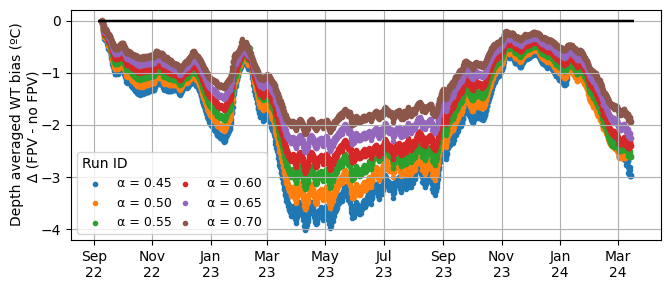

In [47]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6.5,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
legends = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']
runs = list(Dictionary_bias_underFPV.keys())

# Extract numbers and convert to decimal format
alphas = []
for s in runs:
    match = re.search(r"\d+", s)
    if match:
        value = int(match.group()) / 100
        alphas.append(f'α = {value:.2f}')
        
# plot data 
for run in range(0, len(runs), 1):
    temp_plot = Dictionary_bias_underFPV[runs[run]].copy()
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = '.', color = pal.as_hex()[run], zorder = 1, 
               label = alphas[run])
    ax.hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax.grid(True, zorder = -1)

ax.legend(title = "Run ID", loc="lower left", ncol = 2, fontsize = 9, 
               frameon = True, columnspacing = 0.01)._legend_box.align = "left"

# Add formatted date labels
myFmt = mdates.DateFormatter('%b\n%y')
ax.xaxis.set_major_formatter(myFmt)

# ax.set_ylim(-0.5,0.6)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.57, u'Depth averaged WT bias (ºC)\n          Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_depthaveraged.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

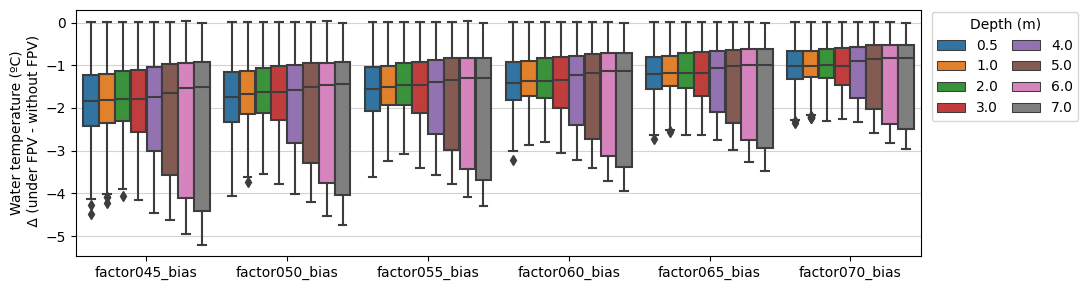

In [43]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [11,3])

pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "run_ID", y = "bias", 
            data = joined_df_boxplot,
            width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax, hue = 'depth')

ax.set_xticks(list(range(0, len(runs), 1)), runs,
              fontsize = 10) 
ax.xaxis.set_label_text("")
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)

ax.yaxis.set_label_text(u'Water temperature (ºC)\n Δ (under FPV - without FPV)', fontsize = 10)
ax.legend(title = "Depth (m)", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(1.195, 1.02))

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'bias_WT_perdepth_boxplot.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

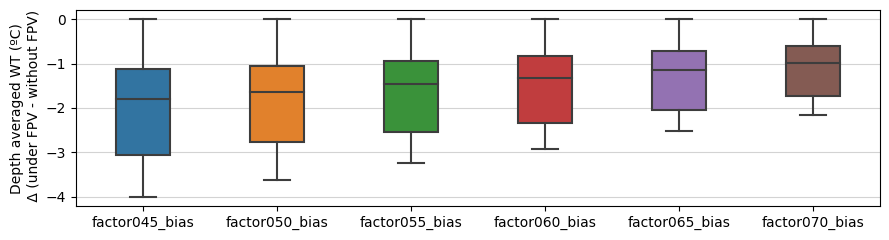

In [44]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,2.5])

pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "run_ID", y = "bias", 
            data = joined_df_bp_average,
            width = 0.4, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax)

ax.set_xticks(list(range(0, len(runs), 1)), runs,
              fontsize = 10) 
ax.xaxis.set_label_text("")
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)

ax.yaxis.set_label_text(u'Depth averaged WT (ºC)\n Δ (under FPV - without FPV)', fontsize = 10)

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'bias_WT_depthaveraged_boxplot.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

# Empirical data

In [49]:
# read files and transform data to correct format
WT_empiricaldata = pd.read_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/data_CNRS/TOTDATA_TempAir.csv', sep = ';')
WT_empiricaldata.drop(WT_empiricaldata.columns[0], axis = 1, inplace = True)
WT_empiricaldata['Day'] = pd.to_datetime(WT_empiricaldata['Day'], format = 'mixed', dayfirst = True)
WT_empiricaldata.set_index('Day', inplace = True)

# WT_empiricaldata['delta_T_compare'] = WT_empiricaldata['Temp_I'] - WT_empiricaldata['Temp_C']
WT_empiricaldata['delta_T_compare'] = (- WT_empiricaldata['DeltaT'])
WT_empiricaldata = WT_empiricaldata.replace(['BAA_PEY', 'POU_SMI', 'SOB_NOU'], ['CA_IA', 'CB_IB', 'CC_IC'])
WT_empiricaldata.tail(2)

,Temp_C,Temp_I,Temp_Air,B_A,PairLake,DeltaT,delta_T_compare
Day,,,,,,,
2023-12-09,9.612385,9.805881,15.5,2) After,CC_IC,-0.193495,0.193495
2023-12-10,9.736038,9.846210,16.1,2) After,CC_IC,-0.110172,0.110172


In [50]:
# plot data for same period of model
WT_empiricaldata_subset = WT_empiricaldata.loc['2022-10-09 00:00:00':'2024-03-08 00:00:00']
# WT_empiricaldata_subset = WT_empiricaldata.loc['2023-02-01 00:00:00':'2024-03-08 00:00:00']

In [51]:
# Organise empirical data to merge with model
pair_lakes = list(WT_empiricaldata_subset.PairLake.unique())

for lake in range(0,len(pair_lakes), 1):
    temp_empirical = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == pair_lakes[lake]]
    temp_empirical = pd.DataFrame(temp_empirical['Temp_C'])
    temp_empirical.rename(columns = {'Temp_C':('Temp_' + pair_lakes[lake][:-3])}, 
                          inplace = True)
    if lake == 0:
        WT_empirical_org = temp_empirical.copy()
    else:
        WT_empirical_org = WT_empirical_org.merge(temp_empirical, on = 'Day')

WT_empirical_org.reset_index(inplace = True)
WT_empirical_org.rename(columns = {'Day':'time'}, inplace = True)
WT_empirical_org.set_index('time', inplace = True)
WT_empirical_org.head(2)

,Temp_CA,Temp_CB,Temp_CC
time,,,
2022-10-09,19.909274,19.624508,19.775671
2022-10-10,19.937629,19.584022,19.806432


In [53]:
# Plot temperature data for all lakes (without FPVs)
comp_WT_noFPV = pd.DataFrame(factor_WT[factor_WT.columns[-1]].copy())
comp_WT_noFPV.rename(columns = {'factor1':'Temp_lakeCAB_alldepths'}, inplace = True)
comp_WT_noFPV = comp_WT_noFPV.resample('D').mean()

temp = pd.DataFrame(factor_WT_surface[factor_WT_surface.columns[-1]].copy())
temp.rename(columns = {'factor1_surface':'Temp_lakeCAB_surface'}, inplace = True)
temp = temp.resample('D').mean()

comp_WT_noFPV = comp_WT_noFPV.merge(temp, on = 'time')

# merge with empirical data
comp_WT_noFPV = comp_WT_noFPV.merge(WT_empirical_org, on = 'time')

comp_WT_noFPV.head(2)

,Temp_lakeCAB_alldepths,Temp_CA,Temp_CB,Temp_CC
time,,,,
2022-10-09,20.389388,19.909274,19.624508,19.775671
2022-10-10,20.341784,19.937629,19.584022,19.806432


<Axes: xlabel='time'>

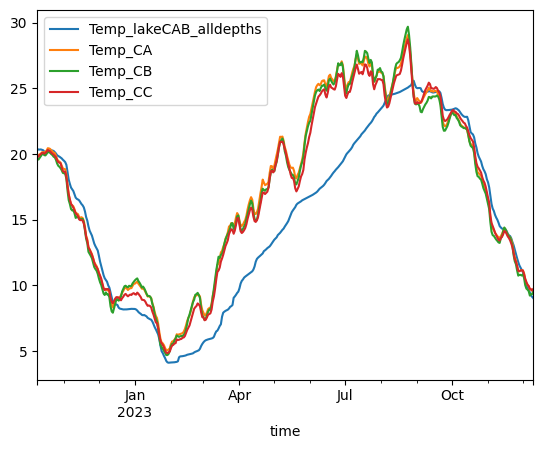

In [54]:
comp_WT_noFPV.plot()

In [55]:
# Organise empirical data to merge with model - BIAS
pair_lakes = list(WT_empiricaldata_subset.PairLake.unique())

for lake in range(0,len(pair_lakes), 1):
    temp_empirical = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == pair_lakes[lake]]
    temp_empirical = pd.DataFrame(temp_empirical['delta_T_compare'])
    temp_empirical.rename(columns = {'delta_T_compare':('bias_' + pair_lakes[lake])}, 
                          inplace = True)
    if lake == 0:
        WTbias_empirical_org = temp_empirical.copy()
    else:
        WTbias_empirical_org = WTbias_empirical_org.merge(temp_empirical, on = 'Day')

WTbias_empirical_org.reset_index(inplace = True)
WTbias_empirical_org.rename(columns = {'Day':'time'}, inplace = True)
WTbias_empirical_org.set_index('time', inplace = True)

WTbias_empirical_org['bias_empirical_av'] = WTbias_empirical_org.mean(axis = 1)

WTbias_empirical_org.head(2)

,bias_CA_IA,bias_CB_IB,bias_CC_IC,bias_empirical_av
time,,,,
2022-10-09,-1.338714,-1.012686,-1.079749,-1.143716
2022-10-10,-1.335529,-0.935320,-1.086442,-1.119097


In [263]:
factor_bias_surface.head(2)

,factor045_surface_bias_surface,factor050_surface_bias_surface,factor055_surface_bias_surface,factor060_surface_bias_surface,factor065_surface_bias_surface,factor070_surface_bias_surface
time,,,,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.006139,0.005562,0.004992,0.004441,0.003908,0.003325


In [31]:
# Plot temperature data for all lakes (without FPVs)
comp_bias_surf = factor_bias_surface.copy()
comp_bias_surf.rename(columns = {'factor1':'bias_lakeCAB_surf'}, inplace = True)
comp_bias_surf = comp_bias_surf.resample('D').mean()

comp_bias_surf = WTbias_empirical_org.merge(comp_bias_surf, on = 'time')

comp_bias_surf.head(2)

,bias_CA_IA,bias_CB_IB,bias_CC_IC,bias_empirical_av,factor1_surface_bias_surface,factor045_surface_bias_surface,9_surface_bias_surface,factor055_surface_bias_surface,factor060_surface_bias_surface,factor065_surface_bias_surface
time,,,,,,,,,,
2022-10-09,-1.338714,-1.012686,-1.079749,-1.143716,0.0,-1.218668,-1.097515,-0.978402,-0.861562,-0.747054
2022-10-10,-1.335529,-0.935320,-1.086442,-1.119097,0.0,-1.261248,-1.135966,-1.012661,-0.891284,-0.772430


In [32]:
# creates monthly df to compare
comp_bias_surf_monthly = comp_bias_surf.resample('M').mean()
comp_bias_surf_monthly.head(2)

,bias_CA_IA,bias_CB_IB,bias_CC_IC,bias_empirical_av,factor1_surface_bias_surface,factor045_surface_bias_surface,9_surface_bias_surface,factor055_surface_bias_surface,factor060_surface_bias_surface,factor065_surface_bias_surface
time,,,,,,,,,,
2022-10-31,-1.104237,-0.789997,-1.034009,-0.976081,0.0,-1.344080,-1.207706,-1.074521,-0.944520,-0.817431
2022-11-30,-0.418492,-0.369614,-0.135184,-0.307764,0.0,-1.285898,-1.173369,-1.063306,-0.955036,-0.846907


Metrics for bias 

In [56]:
# Calculates metrics for each run - whole depth averaged
factor_names = list(daily_WT.run_ID.unique())
r2_list = []
RMSE_list = []
bias_list = []

for run in range(0, len(factor_names), 1):
    temp = daily_WT[daily_WT['run_ID'] == factor_names[run]]
    temp = temp.rename(columns = {'bias':'bias_model'})
    temp = temp.merge(pd.DataFrame(WTbias_empirical_org[WTbias_empirical_org.columns[-1]]), on = 'time')
    n = len(temp)
    
    # metrics
    r2 = ((np.corrcoef(temp[temp.columns[0]], temp[temp.columns[2]])[0,1]) ** 2)
    temp['sq_error'] = ((temp[temp.columns[0]] - temp[temp.columns[2]]) ** 2)
    RMSE = (((1/n) * (temp['sq_error'].sum()) ) ** 0.5)
    bias = (((temp[temp.columns[2]] - temp[temp.columns[0]]).sum()) / n)
        
    # Join results into lists
    r2_list.append(r2)
    RMSE_list.append(RMSE)
    bias_list.append(bias)

print('r²:', r2_list)
print('')
print('RMSD:', RMSE_list)
print('')
print('Bias:', bias_list)

r²: [0.7680082206728114, 0.7581136809817803, 0.7498211794270203, 0.7500548245488668, 0.7387821211855226, 0.7220841098252265]

RMSD: [1.0477400304150102, 0.8525645713816165, 0.6885303238763752, 0.5751327251851089, 0.5110148026249475, 0.5476524063816153]

Bias: [0.9217454503192138, 0.7071026327627828, 0.502692866947756, 0.33020032336318716, 0.11766019163485264, -0.093148325611289]


In [34]:
# Calculates metrics for each run - SURFACE
factor_names = list(daily_WT_surf.run_ID.unique())
r2_surf_list = []
RMSE_surf_list = []
bias_surf_list = []

for run in range(0, len(factor_names), 1):
    temp = daily_WT_surf[daily_WT_surf['run_ID'] == factor_names[run]]
    temp = temp.rename(columns = {'bias':'bias_model'})
    temp = temp.merge(pd.DataFrame(WTbias_empirical_org[WTbias_empirical_org.columns[-1]]), on = 'time')
    n = len(temp)
    
    # metrics
    r2_surf = ((np.corrcoef(temp[temp.columns[0]], temp[temp.columns[2]])[0,1]) ** 2)
    temp['sq_error'] = ((temp[temp.columns[0]] - temp[temp.columns[2]]) ** 2)
    RMSE_surf = (((1/n) * (temp['sq_error'].sum()) ) ** 0.5)
    bias_surf = (((temp[temp.columns[2]] - temp[temp.columns[0]]).sum()) / n)
        
    # Join results into lists
    r2_surf_list.append(r2_surf)
    RMSE_surf_list.append(RMSE_surf)
    bias_surf_list.append(bias_surf)

print('r²:', r2_surf_list)
print('')
print('RMSD:', RMSE_surf_list)
print('')
print('Bias:', bias_surf_list)

r²: [nan, 0.7283155784008631, 0.7198513909985962, 0.7150956373399504, 0.725846426345447, 0.7101225109013106]

RMSD: [1.5912419385937617, 0.9334560516757817, 0.7673163907520589, 0.639611678581117, 0.563205888698378, 0.5566708540742416]

Bias: [-1.2849445523988319, 0.7913890078240547, 0.5846983829099981, 0.38709642438023883, 0.22564367364652577, 0.022690516536685676]


C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [35]:
# Calculates metrics for each run - SURFACE, monthly
factor_names = comp_bias_surf_monthly.columns[4:]
r2_surf_month_list = []
RMSE_surf_month_list = []
bias_surf_month_list = []

for run in range(0, len(factor_names), 1):
    temp = pd.DataFrame(comp_bias_surf_monthly[factor_names[run]])
    factor_id = (factor_names[0][:9])
    
    temp = temp.rename(columns = {temp.columns[0]:('bias_' + factor_id)})
    temp = temp.merge(pd.DataFrame(comp_bias_surf_monthly['bias_empirical_av']), on = 'time')
    n = len(temp)
    
    # metrics
    r2_surf_month = ((np.corrcoef(temp[temp.columns[0]], temp[temp.columns[1]])[0,1]) ** 2)
    temp['sq_error'] = ((temp[temp.columns[0]] - temp[temp.columns[1]]) ** 2)
    RMSE_surf_month = (((1/n) * (temp['sq_error'].sum()) ) ** 0.5)
    bias_surf_month = (((temp[temp.columns[2]] - temp[temp.columns[0]]).sum()) / n)
        
    # Join results into lists
    r2_surf_month_list.append(r2_surf_month)
    RMSE_surf_month_list.append(RMSE_surf_month)
    bias_surf_month_list.append(bias_surf_month)

print('r²:', r2_surf_month_list)
print('')
print('RMSD:', RMSE_surf_month_list)
print('')
print('Bias:', bias_surf_month_list)

C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\midauarg\AppData\Local\Programs\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


r²: [nan, 0.7661562153185781, 0.7618244216209499, 0.7569598982659247, 0.7748057705783287, 0.7614187006105639]

RMSD: [1.5097450570948985, 0.8840741961961283, 0.7146686945823416, 0.5828732255190365, 0.4958183488806627, 0.48378621954603024]

Bias: [2.279330137422478, 2.7768782526184674, 2.306639851506168, 1.9449066334733922, 1.6947383749292664, 1.4873464867559902]


In [36]:
# Creates dfs with error according to run
FPV_metrics = pd.DataFrame()
FPV_metrics['runs'] = factor_names
FPV_metrics['r2_alldepths'] = r2_list
FPV_metrics['r2_surf'] = r2_surf_list
FPV_metrics['r2_surf_month'] = r2_surf_month_list

FPV_metrics['RMSD_alldepths'] = RMSE_list
FPV_metrics['RMSD_surf'] = RMSE_surf_list
FPV_metrics['RMSD_surf_month'] = RMSE_surf_month_list

FPV_metrics['Bias_alldepths'] = bias_list
FPV_metrics['Bias_surf'] = bias_surf_list
FPV_metrics['Bias_surf_month'] = bias_surf_month_list

FPV_metrics

,runs,r2_alldepths,r2_surf,r2_surf_month,RMSD_alldepths,RMSD_surf,RMSD_surf_month,Bias_alldepths,Bias_surf,Bias_surf_month
0,factor1_surface_bias_surface,0.768008,NaN,NaN,1.047740,1.591242,1.509745,0.921745,-1.284945,2.279330
1,factor045_surface_bias_surface,0.758114,0.728316,0.766156,0.852565,0.933456,0.884074,0.707103,0.791389,2.776878
2,9_surface_bias_surface,0.749821,0.719851,0.761824,0.688530,0.767316,0.714669,0.502693,0.584698,2.306640
3,factor055_surface_bias_surface,0.750055,0.715096,0.756960,0.575133,0.639612,0.582873,0.330200,0.387096,1.944907
4,factor060_surface_bias_surface,0.738782,0.725846,0.774806,0.511015,0.563206,0.495818,0.117660,0.225644,1.694738
5,factor065_surface_bias_surface,0.722084,0.710123,0.761419,0.547652,0.556671,0.483786,-0.093148,0.022691,1.487346


In [307]:
FPV_metrics.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/FPV_metrics.csv')

In [37]:
pair_lakes = list(WT_empiricaldata_subset['PairLake'].unique())

for i in pair_lakes:
    temp = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == i]
#     temp = temp.loc['2023-02-01 00:00:00':'2024-03-08 00:00:00']
    print(i + ' yearly average = %.2f' %temp['delta_T_compare'].mean())

print('')
print('Total yearly average (empirical) = %.3f' %temp['delta_T_compare'].mean())
print('')

model_runs = list(daily_WT['run_ID'].unique())
legend = []
for i in range(0,len(model_runs)):
    legend.append(('Model (Factor 0.' + model_runs[i][7:-5] + ')'))

model_runs = list(daily_WT['run_ID'].unique())
for run in range(0, len(model_runs), 1):
    temp_model = daily_WT[daily_WT['run_ID'] == model_runs[run]]
#     temp_model = temp_model.loc['2023-02-01 00:00:00':'2024-03-08 00:00:00']
    print(legend[run][:5] + ' yearly average' + legend[run][5:19] + ' = %.2f' %temp_model['bias'].mean())
    
print('')
model_runs = list(daily_WT_surf['run_ID'].unique())
for run in range(0, len(model_runs), 1):
    temp_model = daily_WT_surf[daily_WT_surf['run_ID'] == model_runs[run]]
#     temp_model = temp_model.loc['2023-02-01 00:00:00':'2024-03-08 00:00:00']
    print(legend[run][:5] + ' yearly average Surface' + legend[run][5:19] + ' = %.2f' %temp_model['bias'].mean())

CA_IA yearly average = -1.53
CB_IB yearly average = -1.11
CC_IC yearly average = -1.20

Total yearly average (empirical) = -1.204

Model yearly average (Factor 0.45) = -2.21
Model yearly average (Factor 0.50) = -1.99
Model yearly average (Factor 0.55) = -1.79
Model yearly average (Factor 0.60) = -1.62
Model yearly average (Factor 0.65) = -1.40
Model yearly average (Factor 0.70) = -1.19

Model yearly average Surface (Factor 0.45) = 0.00
Model yearly average Surface (Factor 0.50) = -2.08
Model yearly average Surface (Factor 0.55) = -1.87
Model yearly average Surface (Factor 0.60) = -1.67
Model yearly average Surface (Factor 0.65) = -1.51
Model yearly average Surface (Factor 0.70) = -1.31


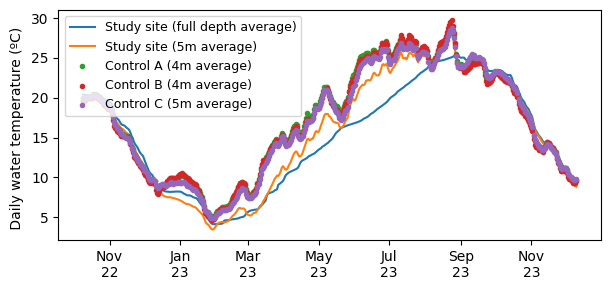

In [46]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)

labels = ['Study site (full depth average)', 'Study site (5m average)', 'Control A (4m average)',
          'Control B (4m average)', 'Control C (5m average)']

for run in range(0, len(comp_WT_noFPV.columns), 1):
    temp_plot = pd.DataFrame(comp_WT_noFPV[comp_WT_noFPV.columns[run]])
    
    if (run<2):
        ax.plot(temp_plot.index, temp_plot[temp_plot.columns[0]],
                color = pal.as_hex()[run], zorder = 1, label = labels[run])
    else:
        ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[0]],
                   marker = '.', color = pal.as_hex()[run], zorder = 1, label = labels[run])

ax.legend(title = "", ncol = 1, fontsize = 9, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

myFmt = mdates.DateFormatter('%b\n%y') # date format with month in string!
ax.xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(wspace = 0, hspace = 0)
 
fig.text(-0.01, 0.55, u' Daily water temperature (ºC)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'WT_empiricalcalib_comparisonBACI.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

In [39]:
figs_path

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_comp/'

In [134]:
Dictionary_bias_underFPV_surface.keys()

dict_keys(['factor045_surface_bias_surface', 'factor050_surface_bias_surface', 'factor055_surface_bias_surface', 'factor060_surface_bias_surface', 'factor065_surface_bias_surface', 'factor070_surface_bias_surface'])

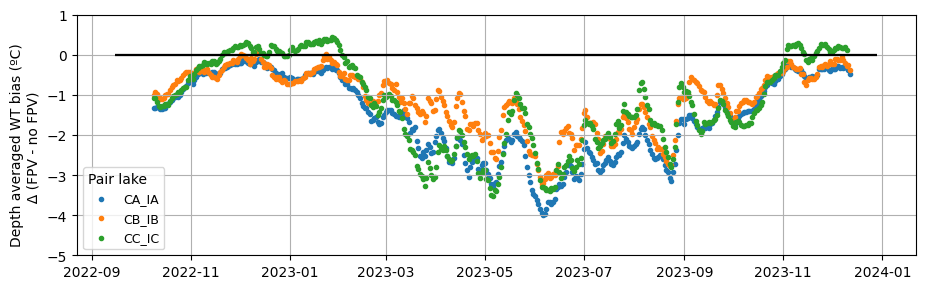

In [80]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
pair_lakes = list(WT_empiricaldata['PairLake'].unique())

for run in range(0, len(pair_lakes), 1):
    temp_plot = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == pair_lakes[run]]
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = '.', color = pal.as_hex()[run], zorder = 1, 
               label = pair_lakes[run])
    ax.hlines(y = 0, xmin = 19250, xmax = 19720, color = 'k')
    ax.grid(True, zorder = -1)

ax.legend(title = "Pair lake", loc="lower left", ncol = 1, fontsize = 9, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

ax.set_ylim(-5,1)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth averaged WT bias (ºC)\n          Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_depthaveraged.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

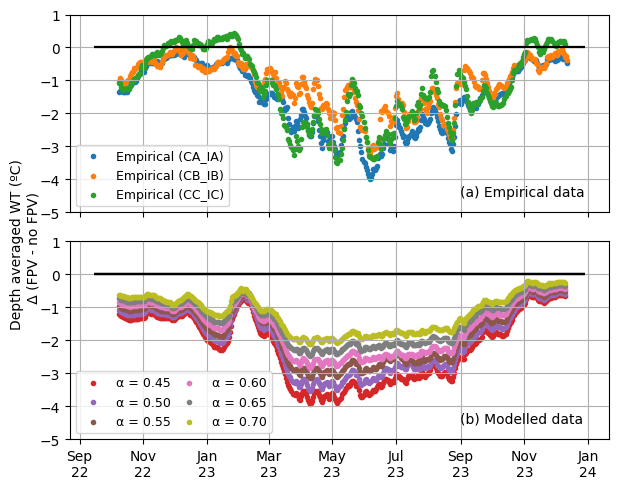

In [88]:
# Plot graph comparing empirical plots and runs
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [6,5], sharey = True, sharex = True)
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)

# empirical data
pair_lakes = list(WT_empiricaldata['PairLake'].unique())

for run in range(0, len(pair_lakes), 1):
    temp_plot = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == pair_lakes[run]]
    ax[1].scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = '.', color = pal.as_hex()[run], zorder = 1, 
               label = ('Empirical ('+ pair_lakes[run] + ')'))
    ax[1].hlines(y = 0, xmin = 19250, xmax = 19720, color = 'k')
    ax[1].grid(True, zorder = -1)

ax[1].legend(loc="lower left", ncol = 1, fontsize = 9, 
             frameon = True, columnspacing = 0.01)._legend_box.align = "left"

# modelling data
model_runs = list(daily_WT['run_ID'].unique())
legend = []
for i in range(0,len(model_runs)):
    legend.append((f'α = 0.' + model_runs[i][7:-5]))
    
for run in range(0, len(model_runs), 1):
    temp_model = daily_WT[daily_WT['run_ID'] == model_runs[run]]
    ax[0].scatter(temp_model.index, temp_model[temp_model.columns[-2]],
               marker = '.', color = pal.as_hex()[run+3], zorder = 1, 
               label = legend[run])
    ax[0].hlines(y = 0, xmin = 19250, xmax = 19720, color = 'k')
    ax[0].grid(True, zorder = -1)

ax[0].legend(ncol = 2, fontsize = 9, columnspacing = 0.5)
    
# ax[1].legend(title = "Model output", ncol = 2, fontsize = 10, 
#              frameon = True, columnspacing = 1, bbox_to_anchor=(1.245, 1.04))

ax[1].set_ylim(-5,1)

ax[1].text(19600, -4.5, '(b) Empirical data', color = 'k', fontsize = 10)
ax[0].text(19600, -4.5, '(a) Modelled data', color = 'k', fontsize = 10)

# Add formatted date labels
myFmt = mdates.DateFormatter('%b\n%y')
ax[0].xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth averaged WT (ºC)\n      Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'empirical_comparison_separateplots.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

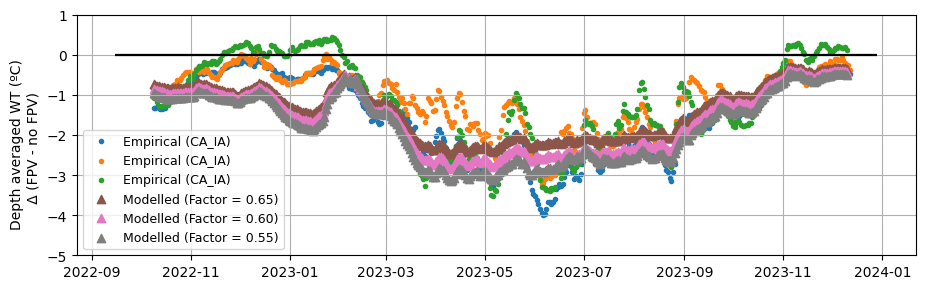

In [83]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
pair_lakes = list(WT_empiricaldata['PairLake'].unique())

for run in range(0, len(pair_lakes), 1):
    temp_plot = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == pair_lakes[run]]
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = '.', color = pal.as_hex()[run], zorder = 1, 
               label = ('Empirical ('+ pair_lakes[0] + ')'))
    ax.hlines(y = 0, xmin = 19250, xmax = 19720, color = 'k')
    ax.grid(True, zorder = -1)

temp_model = daily_WT[daily_WT['run_ID'] == 'factor065_bias']
ax.scatter(temp_model.index, temp_model[temp_model.columns[-2]],
           marker = '^', color = pal.as_hex()[run+3], zorder = 1, 
           label = ('Modelled (Factor = 0.65)'))

temp_model = daily_WT[daily_WT['run_ID'] == 'factor060_bias']
ax.scatter(temp_model.index, temp_model[temp_model.columns[-2]],
           marker = '^', color = pal.as_hex()[run+4], zorder = 1, 
           label = ('Modelled (Factor = 0.60)'))

temp_model = daily_WT[daily_WT['run_ID'] == 'factor055_bias']
ax.scatter(temp_model.index, temp_model[temp_model.columns[-2]],
           marker = '^', color = pal.as_hex()[run+5], zorder = 1, 
           label = ('Modelled (Factor = 0.55)'))
    
ax.legend(loc="lower left", ncol = 1, fontsize = 9, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

ax.set_ylim(-5,1)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth averaged WT (ºC)\n      Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'empirical_comparison_uniqueplot.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

In [50]:
pair_lakes

['BAA_PEY', 'POU_SMI', 'SOB_NOU']

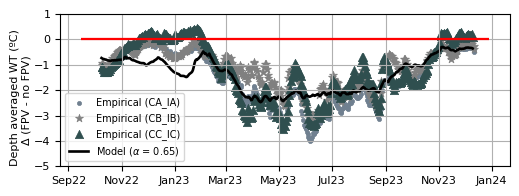

In [329]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [5,2])
pal = sns.color_palette("tab10", 11)
colors = ['slategray', 'grey', 'darkslategray']
markers = ['.', '*', '^']
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
pair_lakes = list(WT_empiricaldata['PairLake'].unique())

for run in range(0, len(pair_lakes), 1):
    temp_plot = WT_empiricaldata_subset[WT_empiricaldata_subset['PairLake'] == pair_lakes[run]]
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = markers[run], linewidths=0.5, color =colors[run], zorder = 1, 
               label = ('Empirical ('+ pair_lakes[run] + ')'))
    ax.hlines(y = 0, xmin = 19250, xmax = 19720, color = 'r')
    ax.grid(True, zorder = -1)

temp_model = daily_WT[daily_WT['run_ID'] == 'factor065_bias']
ax.plot(temp_model.index, temp_model[temp_model.columns[-2]],
        linewidth = 1.9,
        color = 'k', zorder = 1, 
        label = (r'Model ($\alpha$ = 0.65)'))
    
ax.legend(loc="lower left", ncol = 1, fontsize = 7, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

ax.set_ylim(-5,1)

myFmt = mdates.DateFormatter('%b%y') # date format with month in string!
ax.xaxis.set_major_formatter(myFmt)

plt.rcParams.update({'font.size': 8})
ax.tick_params(axis='both', which='major', labelsize=8)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth averaged WT (ºC)\n      Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'empirical_comparison_uniqueplot_065factor.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

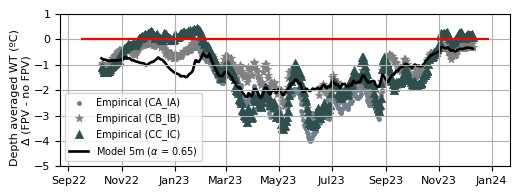

In [39]:
# Plot graph with bias per depth - SURFACE (5M)
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [5,2])
pal = sns.color_palette("tab10", 11)
colors = ['slategray', 'grey', 'darkslategray']
markers = ['.', '*', '^']
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
pair_lakes = list(WT_empiricaldata['PairLake'].unique())

for run in range(0, len(pair_lakes), 1):
    temp_plot = pd.DataFrame(comp_bias_surf[comp_bias_surf.columns[run]])
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[0]],
               marker = markers[run], linewidths=0.5, color =colors[run], zorder = 1, 
               label = ('Empirical ('+ pair_lakes[run] + ')'))
    ax.hlines(y = 0, xmin = 19250, xmax = 19720, color = 'r')
    ax.grid(True, zorder = -1)

temp_model = pd.DataFrame(comp_bias_surf['factor065_surface_bias_surface'])
ax.plot(temp_model.index, temp_model[temp_model.columns[0]],
        linewidth = 1.9,
        color = 'k', zorder = 1, 
        label = (r'Model 5m ($\alpha$ = 0.65)'))
    
ax.legend(loc="lower left", ncol = 1, fontsize = 7, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

ax.set_ylim(-5,1)

myFmt = mdates.DateFormatter('%b%y') # date format with month in string!
ax.xaxis.set_major_formatter(myFmt)

plt.rcParams.update({'font.size': 8})
ax.tick_params(axis='both', which='major', labelsize=8)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth averaged WT (ºC)\n      Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'empirical_surf_065factor_5m.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

In [38]:
figs_path

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_comp/'

In [313]:
comp_bias_surf_monthly.head(1)

,bias_CA_IA,bias_CB_IB,bias_CC_IC,bias_empirical_av,factor045_surface_bias_surface,factor050_surface_bias_surface,factor055_surface_bias_surface,factor060_surface_bias_surface,factor065_surface_bias_surface,factor070_surface_bias_surface
time,,,,,,,,,,
2022-10-31,-1.104237,-0.789997,-1.034009,-0.976081,-1.34408,-1.207706,-1.074521,-0.94452,-0.817431,-0.693592


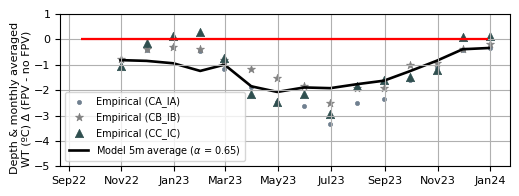

In [333]:
# Plot graph with bias per depth - SURFACE (5M) & monthly
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [5,2])
pal = sns.color_palette("tab10", 11)
colors = ['slategray', 'grey', 'darkslategray']
markers = ['.', '*', '^']
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
pair_lakes = list(WT_empiricaldata['PairLake'].unique())

for run in range(0, len(pair_lakes), 1):
    temp_plot = pd.DataFrame(comp_bias_surf_monthly[comp_bias_surf_monthly.columns[run]])
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[0]],
               marker = markers[run], linewidths=0.5, color =colors[run], zorder = 1, 
               label = ('Empirical ('+ pair_lakes[run] + ')'))
    ax.hlines(y = 0, xmin = 19250, xmax = 19720, color = 'r')
    ax.grid(True, zorder = -1)

temp_model = pd.DataFrame(comp_bias_surf_monthly['factor065_surface_bias_surface'])
ax.plot(temp_model.index, temp_model[temp_model.columns[0]],
        linewidth = 1.9,
        color = 'k', zorder = 1, 
        label = (r'Model 5m average ($\alpha$ = 0.65)'))
    
ax.legend(loc="lower left", ncol = 1, fontsize = 7, 
          frameon = True, columnspacing = 0.01)._legend_box.align = "left"

ax.set_ylim(-5,1)

myFmt = mdates.DateFormatter('%b%y') # date format with month in string!
ax.xaxis.set_major_formatter(myFmt)

plt.rcParams.update({'font.size': 8})
ax.tick_params(axis='both', which='major', labelsize=8)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth & monthly averaged\n  WT (ºC) Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'empirical_surf_monthly_065factor.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

In [86]:
figs_path

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factors_comp/'

# Obsolete

In [6]:
output = xr.open_dataset(output_files[0] + 'trim-FPV_cover49_eqgrid_factor045.nc')

In [8]:
# Creates file with temperature data for specific location
# R1: water temperature | ZK_LYR: Vertical coordinates of layer centres | S1: Water-level in zeta point
output_temp_underFPV = output[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)

In [9]:
# Creates variable with depth of zeta point (S1: Water-level in zeta point - ZK_LYR: Vertical coordinates of layer centres)
output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR

In [10]:
# Creates empty array with dimensions matching (timesteps, measurement points length)
data_modelled = np.empty((len(output_temp_underFPV.time.values), 8))

# calculates temperature per depth (matching measurements) for each timestep
for i in range(len(output_temp_underFPV.time.values)):
    output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
    depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
    temp = output_temp_underFPV_t.R1.values # gets water temperature value
    time = output_temp_underFPV_t.time.values # gets timestep analysed
    temp = temp[depth > 0] # gets temperature values for depth > 0
    depth = depth[depth > 0] # gets depth values > 0
    f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
    data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep

In [11]:
# Creates new dataframe with information on time and depth of the modelled temperature
WT_underFPV_modelled = pd.DataFrame(data_modelled)
times_t = pd.DataFrame(output_temp_underFPV.time.values)
WT_underFPV_modelled['time'] = times_t
WT_underFPV_modelled.set_index('time', inplace = True)
WT_underFPV_modelled.columns = depth_obs_str
WT_underFPV_modelled.head(2)

,0.5m,1m,2m,3m,4m,5m,6m,7m
time,,,,,,,,
2022-09-09 00:00:00,25.645449,25.591359,25.478496,25.359496,25.392140,25.175947,24.767722,24.473604
2022-09-09 06:00:00,25.192474,25.198753,25.209063,25.215055,25.218371,25.217465,24.800751,24.486867
